# XLDS Evaluation Analysis — BART on XSAMSum (English→Chinese)

This notebook analyzes per-pair evaluation scores from the cross-lingual dialogue summarization (XLDS) pipeline, where English dialogue summaries are translated to Chinese. The evaluation file contains ROUGE-1, ROUGE-2, ROUGE-L (with jieba-based Chinese tokenization) and BERTScore F1 (`hfl/chinese-bert-wwm-ext`, layer 8, raw — no baseline rescaling).

**Goals of this notebook**
1. Sanity-check the distribution of each metric.
2. Identify failure modes — where the pipeline collapses (ROUGE=0, low BERTScore).
3. Look at metric agreement — do ROUGE and BERTScore rank the same examples as good/bad?
4. Inspect length effects — does reference length predict score?
5. Surface best / worst / most-disagreed-on examples for qualitative review.

## 1. Load and inspect

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Chinese text rendering in matplotlib — try a few common fonts, fall back silently.
for font in ['Arial Unicode MS', 'Noto Sans CJK SC', 'PingFang SC', 'Heiti TC', 'SimHei', 'DejaVu Sans']:
    try:
        mpl.rcParams['font.sans-serif'] = [font] + mpl.rcParams['font.sans-serif']
        break
    except Exception:
        continue
mpl.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_colwidth', 120)

CSV_PATH = 'pair_scores_zh_XSAMSum_bart.csv'  # adjust if running outside the repo
df = pd.read_csv(CSV_PATH, index_col=0)
print(f'Loaded {len(df)} pairs')
df.head()

Loaded 819 pairs


,reference,prediction,rouge1,rouge2,rougeL,bs_f1_raw
0,汉娜需要贝蒂的电话号码，但阿曼达没有。她得联系拉里。,汉娜不太了解他 阿曼达建议汉娜发短信给他,23.81,15.00,23.81,67.52
1,埃里克和罗伯要在youtube上看一场单口相声。,Eric和Rob正在看一个俄国喜剧演员的脱口秀,28.57,6.06,28.57,63.59
2,莱尼无法决定买哪条裤子。鲍勃就此给莱尼提了些建议。莱尼听了他的建议，选了质量最好的裤子。,Lenny会买两条黑裤子和一条紫色的,18.52,3.85,18.52,58.65
3,艾玛很快就会回家，而且她会告诉威尔。,Emma今晚不想做晚饭 她马上回家 Will会来接她,23.53,6.25,17.65,63.13
4,简在华沙，她和奥利有个聚会。她把重要的日子忘了，本来他们周五会共进午餐。但是奥利无意间给简打了个电话，聊起了威士忌。于是简取消了午餐。下午6点他们见面喝茶。,简从摩洛哥回来了 奥利和简周五下午6点会合吃午餐,34.41,13.19,19.35,68.02


In [2]:
METRICS = ['rouge1', 'rouge2', 'rougeL', 'bs_f1_raw']
df[METRICS].describe().round(2)

,rouge1,rouge2,rougeL,bs_f1_raw
count,819.00,819.00,819.00,819.00
mean,42.46,24.06,35.68,71.14
std,18.20,16.51,17.33,7.87
min,0.00,0.00,0.00,44.86
25%,30.47,12.77,23.53,65.76
50%,41.38,21.28,33.96,71.15
75%,53.22,32.40,45.45,75.98
max,100.00,100.00,100.00,97.52


Quick sanity checks: no missing values, no duplicate references, and reference/prediction are both non-empty.

In [3]:
print('Missing values per column:')
print(df.isna().sum())
print(f"\nEmpty references:  {(df['reference'].str.len() == 0).sum()}")
print(f"Empty predictions: {(df['prediction'].str.len() == 0).sum()}")
print(f"Duplicate references: {df['reference'].duplicated().sum()}")

Missing values per column:
reference     0
prediction    0
rouge1        0
rouge2        0
rougeL        0
bs_f1_raw     0
dtype: int64

Empty references:  0
Empty predictions: 0
Duplicate references: 0


## 2. Metric distributions

ROUGE scores are on a 0–100 scale; BERTScore F1 is reported raw (no baseline rescaling per our evaluation setup), so it sits in the 40–100 range typical for `bert-base-chinese` unrescaled.

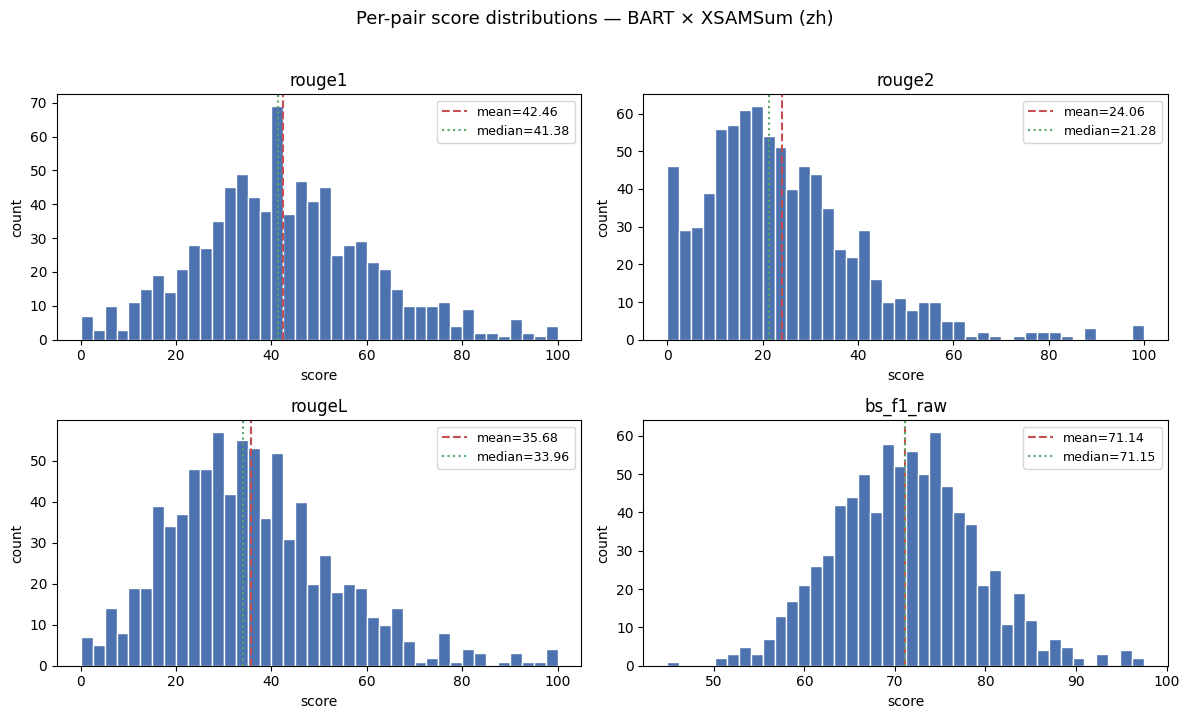

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, metric in zip(axes.ravel(), METRICS):
    ax.hist(df[metric], bins=40, color='#4C72B0', edgecolor='white')
    mean_val = df[metric].mean()
    median_val = df[metric].median()
    ax.axvline(mean_val, color='#C44E52', linestyle='--', linewidth=1.5, label=f'mean={mean_val:.2f}')
    ax.axvline(median_val, color='#55A868', linestyle=':', linewidth=1.5, label=f'median={median_val:.2f}')
    ax.set_title(metric)
    ax.set_xlabel('score')
    ax.set_ylabel('count')
    ax.legend(fontsize=9)
fig.suptitle('Per-pair score distributions — BART × XSAMSum (zh)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

/tmp/ipykernel_68/1214455913.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot([df['rouge1'], df['rouge2'], df['rougeL']], labels=['R-1', 'R-2', 'R-L'], showmeans=True)
/tmp/ipykernel_68/1214455913.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([df['bs_f1_raw']], labels=['BERTScore F1'], showmeans=True)


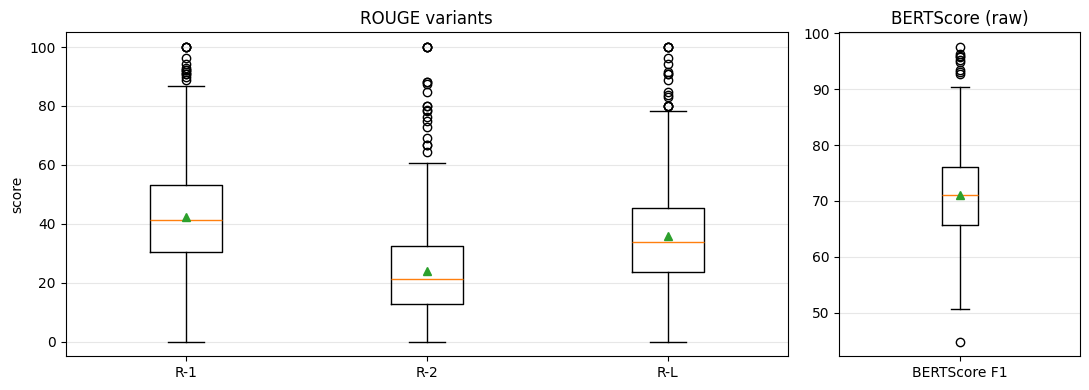

In [5]:
# Boxplot view — easier for comparing the three ROUGE variants side by side.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={'width_ratios': [3, 1]})
ax1.boxplot([df['rouge1'], df['rouge2'], df['rougeL']], labels=['R-1', 'R-2', 'R-L'], showmeans=True)
ax1.set_title('ROUGE variants')
ax1.set_ylabel('score')
ax1.grid(axis='y', alpha=0.3)
ax2.boxplot([df['bs_f1_raw']], labels=['BERTScore F1'], showmeans=True)
ax2.set_title('BERTScore (raw)')
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Failure modes

How often does the pipeline completely miss? A ROUGE-1 of 0 means zero unigram overlap with the reference after jieba segmentation — essentially no lexical match at all.

In [6]:
zero_r1 = (df['rouge1'] == 0).sum()
zero_r2 = (df['rouge2'] == 0).sum()
zero_rl = (df['rougeL'] == 0).sum()
low_bs = (df['bs_f1_raw'] < 55).sum()

print(f"ROUGE-1 == 0:         {zero_r1:4d}  ({zero_r1/len(df):.1%})")
print(f"ROUGE-2 == 0:         {zero_r2:4d}  ({zero_r2/len(df):.1%})")
print(f"ROUGE-L == 0:         {zero_rl:4d}  ({zero_rl/len(df):.1%})")
print(f"BERTScore F1 < 55:    {low_bs:4d}  ({low_bs/len(df):.1%})")

# Joint failure — both lexical and semantic signals say 'bad'.
joint_fail = df[(df['rouge1'] < 10) & (df['bs_f1_raw'] < 60)]
print(f"\nJoint low (R-1 < 10 AND BS < 60): {len(joint_fail)}  ({len(joint_fail)/len(df):.1%})")

ROUGE-1 == 0:            7  (0.9%)
ROUGE-2 == 0:           44  (5.4%)
ROUGE-L == 0:            7  (0.9%)
BERTScore F1 < 55:      13  (1.6%)

Joint low (R-1 < 10 AND BS < 60): 21  (2.6%)


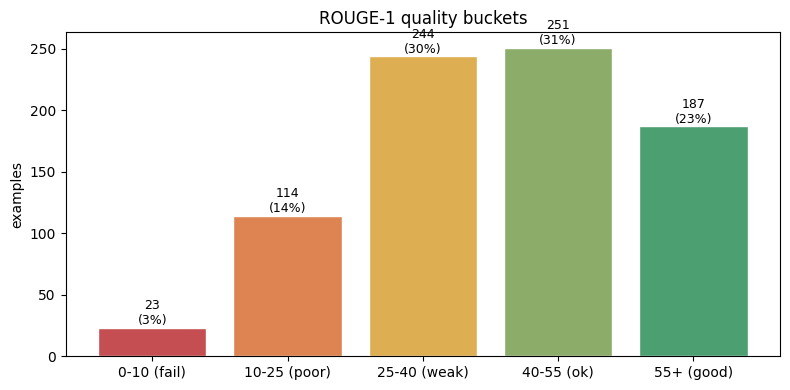

In [7]:
# Threshold buckets for ROUGE-1 — a quick quality histogram.
bins = [-0.01, 10, 25, 40, 55, 100.01]
labels = ['0-10 (fail)', '10-25 (poor)', '25-40 (weak)', '40-55 (ok)', '55+ (good)']
df['r1_bucket'] = pd.cut(df['rouge1'], bins=bins, labels=labels)
bucket_counts = df['r1_bucket'].value_counts().reindex(labels)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#C44E52', '#DD8452', '#DDAE52', '#8CAD6A', '#4C9F70']
bars = ax.bar(bucket_counts.index, bucket_counts.values, color=colors, edgecolor='white')
for bar, count in zip(bars, bucket_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{count}\n({count/len(df):.0%})', ha='center', fontsize=9)
ax.set_title('ROUGE-1 quality buckets')
ax.set_ylabel('examples')
plt.tight_layout()
plt.show()

## 4. Metric agreement

Do ROUGE and BERTScore rank examples similarly? ROUGE is purely lexical (after jieba segmentation); BERTScore uses contextual embeddings, so it rewards paraphrases that ROUGE punishes. Strong correlation = metrics agree; weak correlation = they capture different things.

In [8]:
pearson = df[METRICS].corr(method='pearson').round(3)
spearman = df[METRICS].corr(method='spearman').round(3)

print('Pearson (linear):')
print(pearson)
print('\nSpearman (rank):')
print(spearman)

Pearson (linear):
           rouge1  rouge2  rougeL  bs_f1_raw
rouge1      1.000    0.91   0.919      0.919
rouge2      0.910    1.00   0.910      0.870
rougeL      0.919    0.91   1.000      0.887
bs_f1_raw   0.919    0.87   0.887      1.000

Spearman (rank):
           rouge1  rouge2  rougeL  bs_f1_raw
rouge1      1.000   0.911   0.906      0.902
rouge2      0.911   1.000   0.891      0.872
rougeL      0.906   0.891   1.000      0.864
bs_f1_raw   0.902   0.872   0.864      1.000


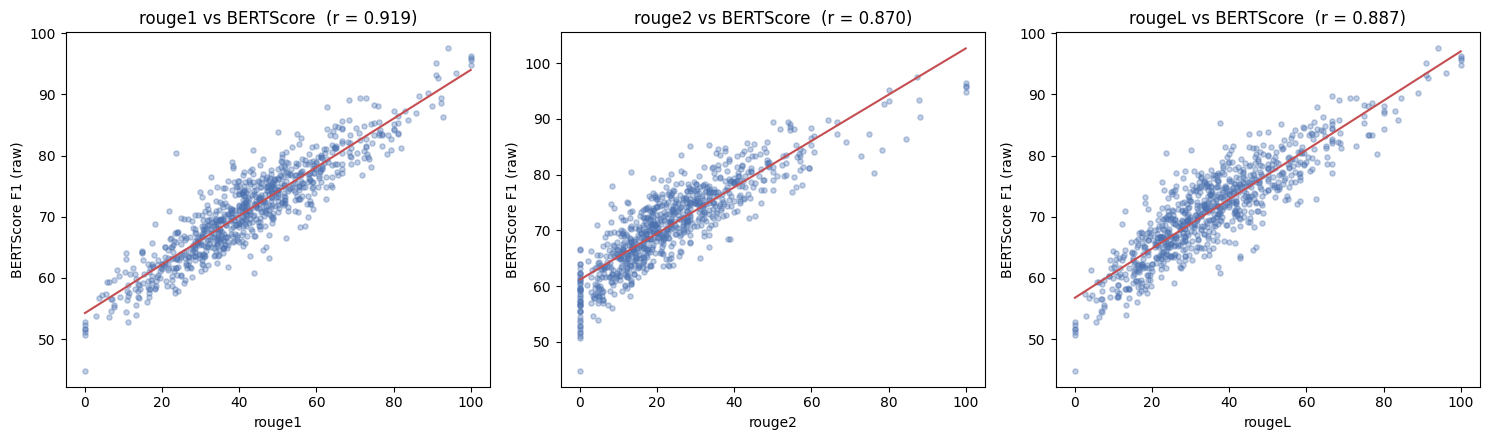

In [9]:
# Scatter: ROUGE-1 vs BERTScore. The gap between ROUGE=0 and a reasonable BERTScore tells us how often
# the model produces a semantically plausible Chinese summary with different lexical choices than the reference.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, metric in zip(axes, ['rouge1', 'rouge2', 'rougeL']):
    ax.scatter(df[metric], df['bs_f1_raw'], alpha=0.35, s=14, color='#4C72B0')
    r = df[[metric, 'bs_f1_raw']].corr().iloc[0, 1]
    ax.set_xlabel(metric)
    ax.set_ylabel('BERTScore F1 (raw)')
    ax.set_title(f'{metric} vs BERTScore  (r = {r:.3f})')
    # Trend line
    z = np.polyfit(df[metric], df['bs_f1_raw'], 1)
    xs = np.linspace(df[metric].min(), df[metric].max(), 50)
    ax.plot(xs, np.poly1d(z)(xs), color='#C44E52', linewidth=1.5)
plt.tight_layout()
plt.show()

## 5. Length effects

In dialogue summarization, reference length varies a lot. Short references are often "one-liner" summaries where a single missed content word collapses ROUGE to 0. Let's check whether score depends on reference length.

In [10]:
df['ref_len'] = df['reference'].str.len()      # char count — more meaningful than word count for Chinese.
df['pred_len'] = df['prediction'].str.len()
df['len_ratio'] = df['pred_len'] / df['ref_len'].clip(lower=1)

print('Reference length (chars):')
print(df['ref_len'].describe().round(1))
print('\nPrediction length (chars):')
print(df['pred_len'].describe().round(1))

Reference length (chars):
count    819.0
mean      35.1
std       18.8
min        6.0
25%       20.0
50%       31.0
75%       46.0
max      118.0
Name: ref_len, dtype: float64

Prediction length (chars):
count    819.0
mean      30.4
std       18.0
min        4.0
25%       18.0
50%       26.0
75%       37.0
max      143.0
Name: pred_len, dtype: float64


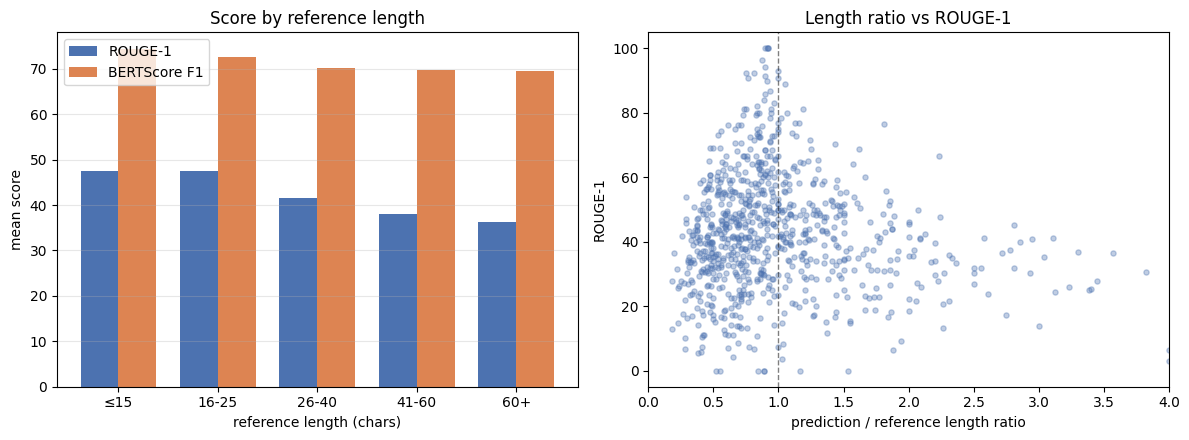

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Binned mean score by reference length.
df['len_bin'] = pd.cut(df['ref_len'], bins=[0, 15, 25, 40, 60, 1000],
                        labels=['≤15', '16-25', '26-40', '41-60', '60+'])
grouped = df.groupby('len_bin', observed=True)[['rouge1', 'bs_f1_raw']].mean()
x = np.arange(len(grouped))
width = 0.38
axes[0].bar(x - width/2, grouped['rouge1'], width, label='ROUGE-1', color='#4C72B0')
axes[0].bar(x + width/2, grouped['bs_f1_raw'], width, label='BERTScore F1', color='#DD8452')
axes[0].set_xticks(x)
axes[0].set_xticklabels(grouped.index)
axes[0].set_xlabel('reference length (chars)')
axes[0].set_ylabel('mean score')
axes[0].set_title('Score by reference length')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Length ratio vs ROUGE-1. Ratios far from 1.0 suggest the model is over- or under-generating.
axes[1].scatter(df['len_ratio'], df['rouge1'], alpha=0.35, s=14, color='#4C72B0')
axes[1].axvline(1.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_xlabel('prediction / reference length ratio')
axes[1].set_ylabel('ROUGE-1')
axes[1].set_title('Length ratio vs ROUGE-1')
axes[1].set_xlim(0, 4)
plt.tight_layout()
plt.show()

## 6. Qualitative inspection

Ranked lists of interesting examples for manual review.

In [12]:
def show(subset, title):
    print(f'\n{"="*4} {title} {"="*4}')
    return subset[['reference', 'prediction', 'rouge1', 'rougeL', 'bs_f1_raw']].reset_index(drop=True)

# Top 5 by ROUGE-L
show(df.nlargest(5, 'rougeL'), 'TOP 5 by ROUGE-L')


==== TOP 5 by ROUGE-L ====


,reference,prediction,rouge1,rougeL,bs_f1_raw
0,迈克、汤姆和本要去喝啤酒。,"迈克,汤姆和本要去喝啤酒",100.0,100.0,94.89
1,艾莉森拿到奖学金了。,艾莉森拿到奖学金了,100.0,100.0,96.36
2,娜塔莉的钱包在她房间里。,娜塔莉的钱包在她房间里,100.0,100.0,95.96
3,珍妮特的厨房里有老鼠。,珍妮特的厨房里有老鼠,100.0,100.0,95.71
4,利亚姆和内特15分钟后自会见面。,利亚姆和内特15分钟后会见面,96.3,96.3,93.43


In [13]:
show(df.nsmallest(5, 'rougeL'), 'BOTTOM 5 by ROUGE-L')


==== BOTTOM 5 by ROUGE-L ====


,reference,prediction,rouge1,rougeL,bs_f1_raw
0,霍莉和艾米打招呼，但是艾米工作很忙，现在没有时间聊天。,Amy晚点会回Hollie的,0.0,0.0,51.68
1,卡洛琳和梅根玩猜谜游戏——他们需要猜出一句话来自哪部电影。,Caroline差点又拉上睾丸了,0.0,0.0,51.70
2,埃琳娜穿着红色的夹克，杰弗里没看到她，也没看到汤姆。,Tom和Jeffrey离Elena只有几米远,0.0,0.0,51.09
3,出于嫉妒，亚莉克莎让伊桑去侮辱亨特。,Alexa和Hunter明天再谈,0.0,0.0,50.67
4,布鲁克要盖尔过来看看昨天发生了什么。,Gyle正在去见Brook的路上,0.0,0.0,52.78


In [14]:
# Examples where the two metrics strongly disagree — these are diagnostic for paraphrase vs. lexical mismatch.
# Z-score each metric, then rank by the absolute difference.
df['_r1_z'] = (df['rouge1'] - df['rouge1'].mean()) / df['rouge1'].std()
df['_bs_z'] = (df['bs_f1_raw'] - df['bs_f1_raw'].mean()) / df['bs_f1_raw'].std()
df['_gap'] = df['_bs_z'] - df['_r1_z']   # positive => BERTScore rewards it more than ROUGE-1 does

print('BERTScore rewards, ROUGE-1 penalizes — likely paraphrase / synonym choice:')
show(df.nlargest(5, '_gap'), '')

BERTScore rewards, ROUGE-1 penalizes — likely paraphrase / synonym choice:

====  ====


,reference,prediction,rouge1,rougeL,bs_f1_raw
0,爱米利娅还在生气。,艾蜜莉亚仍然很生气,23.53,23.53,80.44
1,詹姆斯要去上班，所以他不看比赛。,詹姆斯会去工作。,38.10,38.10,79.02
2,威廉正在做意大利面条当晚餐。这是一道意大利菜，里面有意大利面、大蒜、葡萄酒和蛤蜊。,威廉姆会准备意大利面 ALLAVONGOLE晚餐。,32.65,32.65,76.57
3,奥布里安娜朋友的父亲在刚果因疟疾病逝。,奥布里安纳的朋友的爸爸死于孔戈的疟疾。,50.00,50.00,83.84
4,丹看过《惩罚者》第二季，埃里克觉得第一季比第二季好。他们都觉得《夜魔侠》停播很可惜。,"Eric 和 Dan 都看《惩罚者》第二季,他们认为比第一季好。他们都认为Netflix 终止了《达雷多邪恶》。",43.48,40.58,80.99


In [15]:
print('ROUGE-1 rewards, BERTScore penalizes — likely word overlap without shared meaning:')
show(df.nsmallest(5, '_gap'), '')

ROUGE-1 rewards, BERTScore penalizes — likely word overlap without shared meaning:

====  ====


,reference,prediction,rouge1,rougeL,bs_f1_raw
0,玛丽和莉莉会facetime软件上给凯尔打电话。,Lily和Mary十分钟后会通过Facetime打电话给Kyle,43.75,37.50,60.82
1,杰会借钱给乔买活动的门票，露丝和波莱特会陪着他们。,Jay会借钱给Joe买票的 Jay已经说服Ruth和Paulette陪他,47.62,42.86,63.26
2,黛西要把她的rgs申请表寄给斯嘉丽。,Daisy已经给Scarlett寄了她的RGS申请表,57.14,42.86,68.51
3,如果商店里有梨味酸奶， 皮特会给珍买的。,皮特想买梨酸奶 珍只要他们有就买 如果他们没有 她不喜欢别的口味,52.17,26.09,66.59
4,维克多这个星期六很忙，所以不能给萨拉他们正在组织的活动帮忙。,Victor帮不了Sara这个星期六组织的活动,55.81,46.51,68.38


## 7. Summary table

A single-row summary you can drop straight into the results section of the write-up, matching the ClidSum Table 3 format.

In [16]:
summary = pd.DataFrame({
    'model': ['BART'],
    'dataset': ['XSAMSum (zh)'],
    'n': [len(df)],
    'ROUGE-1': [df['rouge1'].mean().round(2)],
    'ROUGE-2': [df['rouge2'].mean().round(2)],
    'ROUGE-L': [df['rougeL'].mean().round(2)],
    'BERTScore F1': [df['bs_f1_raw'].mean().round(2)],
    'R-1 fails (==0)': [int((df['rouge1'] == 0).sum())],
})
summary

,model,dataset,n,ROUGE-1,ROUGE-2,ROUGE-L,BERTScore F1,R-1 fails (==0)
0,BART,XSAMSum (zh),819,42.46,24.06,35.68,71.14,7


## Notes / follow-ups

- **BERTScore is raw** (not baseline-rescaled), so absolute numbers aren't directly comparable to papers that report rescaled scores. The *relative* ordering across runs is still valid.
- A non-trivial fraction of ROUGE=0 cases often have decent BERTScore — those are worth inspecting: they're typically valid paraphrases that jieba segments into different tokens than the reference.